In [6]:
%matplotlib inline

In [1]:
# ============================================================
# Task 1 full notebook pipeline
# 10 random k=5 mixtures
# - separate scatter plots
# - one multi-subplot bar figure
# Uses the SAME selected mixtures for both
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
import data_loading
import deconv_data
import deconv_model

from utils import (
    build_label_map,
    extract_sample_labels,
    build_centroids,
    apply_label_map,
    select_probes_from_centroids,
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
SPLIT_PATH = Path("/home/jullid/projects/mouse-DNA-project/results/deconvolution/split.json")

# Rebuild / rerun settings
N_MIXTURES = 1000
K_MIN = 5
K_MAX = 5
MIXTURE_SEED = 123

# Plot selection settings
N_SELECTED_MIXTURES = 10
PLOT_RANDOM_SEED = 42
ANNOTATE_SCATTER_POINTS = False   # toggle to True if you want tissue labels



In [2]:
# ------------------------------------------------------------
# Helper 1: rebuild the deconvolution run in the notebook
# using the SAME saved split, but regenerate mixtures with k=5
# ------------------------------------------------------------
def prepare_deconv_run_for_notebook(
    split_path: Path,
    k_min: int,
    k_max: int,
    n_mixtures: int = 1000,
    mixture_seed: int = 123,
):
    """
    Rebuild the reference atlas from the saved split, rerun probe selection
    from the reference-only centroids, regenerate synthetic mixtures with
    the requested k-range, and deconvolve them.
    """
    # Load raw methylation data
    df_raw, _, _, _ = data_loading.load_all()

    # Build label map from project merge groups
    label_map = build_label_map(data_loading.MERGE_GROUPS)

    # Extract original tissue labels from df_raw sample column names
    original_labels_all = extract_sample_labels(df_raw)

    # Remove excluded tissues, matching the pipeline logic
    _, _ = apply_label_map(
        original_labels_all,
        label_map,
        excluded_tissues=data_loading.EXCLUDED_TISSUES,
    )
    keep_mask = ~original_labels_all.isin(data_loading.EXCLUDED_TISSUES)
    original_labels = original_labels_all[keep_mask]

    # Load the SAME saved reference/pool split
    reference_cols, pool_cols = deconv_data.load_split(split_path)

    # Build reference centroids from the saved reference split only
    df_merged_ref = build_centroids(
        df_raw=df_raw,
        sample_cols=reference_cols,
        original_labels=original_labels,
        merge_groups=data_loading.MERGE_GROUPS,
    )

    # Rerun probe selection from the reference-only centroids
    selected_probes = select_probes_from_centroids(df_merged_ref)

    # Build W on the selected probes
    W_masked = deconv_data.build_reference_matrix(
        df_raw=df_raw,
        reference_cols=reference_cols,
        original_labels=original_labels,
        selected_probes=selected_probes,
    )

    # Determine eligible tissues in the pool
    eligible_tissues = deconv_data.get_eligible_tissues(
        pool_cols=pool_cols,
        original_labels=original_labels,
        label_map=label_map,
        min_pool_replicates=config.DECONV_MIN_POOL_REPLICATES,
    )

    # Generate synthetic mixtures with fixed k
    X_mixtures, df_proportions = deconv_data.generate_synthetic_mixtures(
        df_raw=df_raw,
        pool_cols=pool_cols,
        original_labels=original_labels,
        label_map=label_map,
        selected_probes=selected_probes,
        eligible_tissues=eligible_tissues,
        n_mixtures=n_mixtures,
        k_min=k_min,
        k_max=k_max,
        dirichlet_alpha=config.DECONV_DIRICHLET_ALPHA,
        random_state=mixture_seed,
    )

    # Run NNLS deconvolution against the full 20-tissue reference atlas
    df_estimated, residuals = deconv_model.deconvolve_batch(W_masked, X_mixtures)

    # Per-mixture metrics
    df_mixture_metrics = deconv_model.compute_per_mixture_metrics(
        df_proportions,
        df_estimated,
    )

    return {
        "df_raw": df_raw,
        "original_labels": original_labels,
        "label_map": label_map,
        "reference_cols": reference_cols,
        "pool_cols": pool_cols,
        "df_merged_ref": df_merged_ref,
        "selected_probes": selected_probes,
        "W_masked": W_masked,
        "eligible_tissues": eligible_tissues,
        "X_mixtures": X_mixtures,
        "df_proportions": df_proportions,
        "df_estimated": df_estimated,
        "residuals": residuals,
        "df_mixture_metrics": df_mixture_metrics,
    }


# ------------------------------------------------------------
# Helper 2: select random k=5 mixtures ONCE
# so both scatter and bar plots use the same mixture IDs
# ------------------------------------------------------------
def select_random_k_mixtures(
    df_proportions: pd.DataFrame,
    k: int,
    n_plots: int = 10,
    random_seed: int = 42,
):
    """
    Select random mixture IDs with exactly k non-zero components.
    """
    n_components = (df_proportions > 0).sum(axis=1)
    valid_ids = n_components[n_components == k].index.tolist()

    if len(valid_ids) < n_plots:
        raise ValueError(
            f"Requested {n_plots} mixtures with k={k}, but only found {len(valid_ids)}."
        )

    rng = np.random.RandomState(random_seed)
    chosen_ids = rng.choice(valid_ids, size=n_plots, replace=False).tolist()
    return chosen_ids


# ------------------------------------------------------------
# Helper 3: scatter plots
# Same geometry/style as codebase scatter, with added:
# - color by tissue
# - legend
# - mixture title
# ------------------------------------------------------------
def plot_selected_mixture_scatters(
    df_proportions: pd.DataFrame,
    df_estimated: pd.DataFrame,
    mixture_ids: list,
    annotate_points: bool = False,
):
    """
    Make one scatter plot per supplied mixture ID.

    Includes tissues where NOT (true == 0 and predicted == 0).
    """
    tissues = list(df_estimated.columns)
    cmap = plt.cm.get_cmap("tab20", len(tissues))
    tissue_to_color = {t: cmap(i) for i, t in enumerate(tissues)}

    for mix_id in mixture_ids:
        true_vals = df_proportions.loc[mix_id]
        pred_vals = df_estimated.loc[mix_id]

        # Keep tissues where either truth or prediction is non-zero
        mask = ~((true_vals == 0) & (pred_vals == 0))
        true_plot = true_vals[mask]
        pred_plot = pred_vals[mask]

        fig, ax = plt.subplots(figsize=(7, 7))

        for tissue in true_plot.index:
            x = true_plot.loc[tissue]
            y = pred_plot.loc[tissue]

            ax.scatter(
                x,
                y,
                alpha=0.8,
                s=30,
                color=tissue_to_color[tissue],
                label=tissue,
            )

            if annotate_points:
                ax.text(
                    x + 0.01,
                    y + 0.01,
                    tissue,
                    fontsize=7,
                )

        # Match codebase scatter style
        ax.plot([0, 1], [0, 1], "r--", linewidth=0.8, alpha=0.7)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_aspect("equal")
        ax.tick_params(labelsize=8)

        ax.set_xlabel("True proportion", fontsize=10)
        ax.set_ylabel("Estimated proportion", fontsize=10)
        ax.set_title(mix_id, fontsize=10)

        # Deduplicate legend entries
        handles, labels = ax.get_legend_handles_labels()
        seen = set()
        uniq_handles = []
        uniq_labels = []
        for h, l in zip(handles, labels):
            if l not in seen:
                uniq_handles.append(h)
                uniq_labels.append(l)
                seen.add(l)

        ax.legend(
            uniq_handles,
            uniq_labels,
            title="Tissue",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
            fontsize=7,
            title_fontsize=8,
            frameon=True,
        )

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# Helper 4: grouped bar plots for the SAME selected mixtures
# ------------------------------------------------------------
def plot_selected_mixture_barplots(
    df_proportions: pd.DataFrame,
    df_estimated: pd.DataFrame,
    mixture_ids: list,
):
    """
    Plot grouped bar plots for the supplied mixture IDs.

    Specifications:
    - one figure with multiple subplots
    - only include tissues where NOT (true == 0 and predicted == 0)
    - sort tissues within each mixture by true proportion descending
    - color by tissue identity
    - true vs predicted distinguished by alpha
    - legends for both tissue identity and true/pred mapping
    - fixed y-axis [0, 1]
    """
    from matplotlib.patches import Patch

    n_plots = len(mixture_ids)

    # Use a 2x5 grid for 10 mixtures, else compute compact grid
    if n_plots == 10:
        n_rows, n_cols = 2, 5
    else:
        n_cols = min(5, n_plots)
        n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    tissues = list(df_estimated.columns)
    cmap = plt.cm.get_cmap("tab20", len(tissues))
    tissue_to_color = {t: cmap(i) for i, t in enumerate(tissues)}

    bar_width = 0.38

    for ax, mix_id in zip(axes, mixture_ids):
        true_vals = df_proportions.loc[mix_id]
        pred_vals = df_estimated.loc[mix_id]

        # Keep tissues where either truth or prediction is non-zero
        mask = ~((true_vals == 0) & (pred_vals == 0))
        true_plot = true_vals[mask]
        pred_plot = pred_vals[mask]

        # Sort tissues by true proportion descending within each mixture
        order = true_plot.sort_values(ascending=False).index.tolist()
        true_plot = true_plot.loc[order]
        pred_plot = pred_plot.loc[order]

        x = np.arange(len(order))
        tissue_colors = [tissue_to_color[t] for t in order]

        # True bars
        ax.bar(
            x - bar_width / 2,
            true_plot.values,
            width=bar_width,
            color=tissue_colors,
            alpha=0.95,
            edgecolor="black",
            linewidth=0.6,
            label="True",
        )

        # Predicted bars
        ax.bar(
            x + bar_width / 2,
            pred_plot.values,
            width=bar_width,
            color=tissue_colors,
            alpha=0.45,
            edgecolor="black",
            linewidth=0.6,
            label="Predicted",
        )

        ax.set_title(mix_id, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks(x)
        ax.set_xticklabels(order, rotation=90, fontsize=7)
        ax.tick_params(axis="y", labelsize=8)
        ax.set_ylabel("Proportion", fontsize=9)

    # Hide any unused subplot axes
    for j in range(len(mixture_ids), len(axes)):
        axes[j].set_visible(False)

    # Legend for true vs predicted styling
    style_handles = [
        Patch(facecolor="grey", edgecolor="black", alpha=0.95, label="True"),
        Patch(facecolor="grey", edgecolor="black", alpha=0.45, label="Predicted"),
    ]

    # Legend for tissue identity
    tissue_handles = [
        Patch(facecolor=tissue_to_color[t], edgecolor="black", label=t)
        for t in tissues
    ]

    fig.legend(
        handles=style_handles,
        loc="upper left",
        bbox_to_anchor=(1.01, 0.98),
        title="Bar type",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
    )

    fig.legend(
        handles=tissue_handles,
        loc="upper left",
        bbox_to_anchor=(1.01, 0.55),
        title="Tissue",
        fontsize=7,
        title_fontsize=9,
        frameon=True,
        ncol=1,
    )

    fig.suptitle(
        "True vs predicted tissue proportions for 10 random k=5 mixtures",
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 0.82, 0.96])
    plt.show()

In [3]:
# ============================================================
# Run the full notebook workflow
# ============================================================

# Step 1: rebuild the k=5 deconvolution run
task1 = prepare_deconv_run_for_notebook(
    split_path=SPLIT_PATH,
    k_min=K_MIN,
    k_max=K_MAX,
    n_mixtures=N_MIXTURES,
    mixture_seed=MIXTURE_SEED,
)


Excluded 20 samples from: {'Mammary_Glands', 'Sciatic_Nerve', 'Optic_Nerve'}
Remaining samples: 247

Sample counts per merged tissue class:
merged_tissue
Adrenal                      6
Bile_Duct                    6
Blood_Spleen_Thymus         30
Brain_Cortex_Subcortical    25
Cerebellum                   9
Colon                       11
Diaphragm                    6
Eye_Retina                  17
Femur                       10
Heart                       10
Kidney                      12
Liver                       26
Lung                        10
Pancreas                     7
Skin_Ears_Tail              31
Spinal_Cord                  6
Stomach                      5
Testis                      10
Urinary_Bladder              6
Uterus                       4
Name: count, dtype: int64
Loaded split from /home/jullid/projects/mouse-DNA-project/results/deconvolution/split.json
  Reference fraction: 0.5
  Split seed: 42
  Reference: 119 samples
  Pool: 128 samples
Reference matrix W sh

In [4]:
# Step 2: select the same 10 mixtures once
selected_mixture_ids = select_random_k_mixtures(
    df_proportions=task1["df_proportions"],
    k=5,
    n_plots=N_SELECTED_MIXTURES,
    random_seed=PLOT_RANDOM_SEED,
)

print("Selected mixture IDs:")
print(selected_mixture_ids)


Selected mixture IDs:
['mixture_521', 'mixture_737', 'mixture_740', 'mixture_660', 'mixture_411', 'mixture_678', 'mixture_626', 'mixture_513', 'mixture_859', 'mixture_136']


/tmp/ipykernel_888361/1123434496.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(tissues))


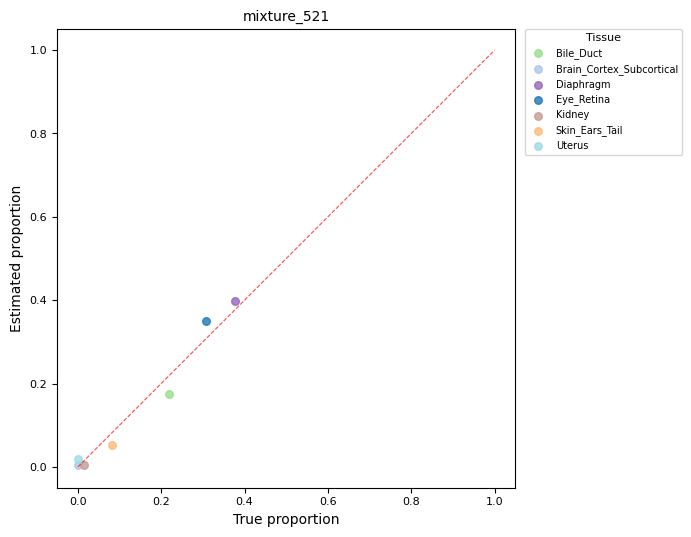

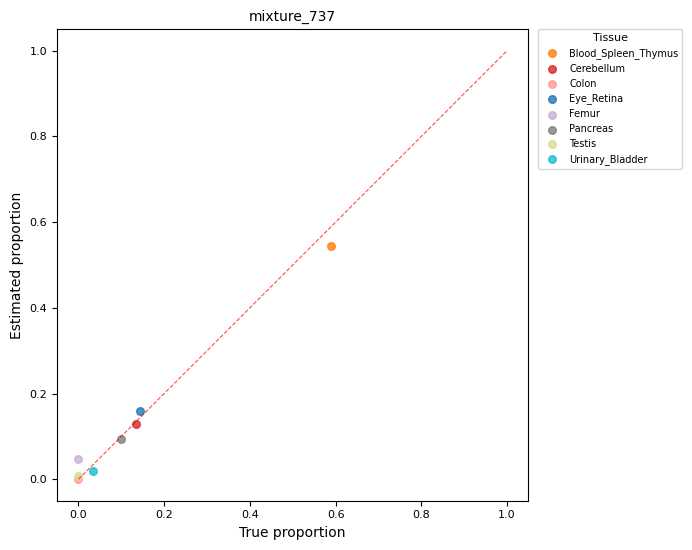

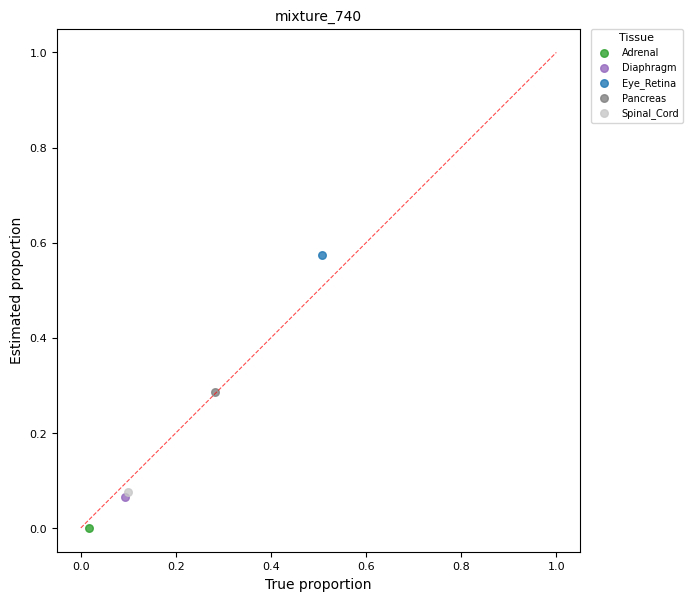

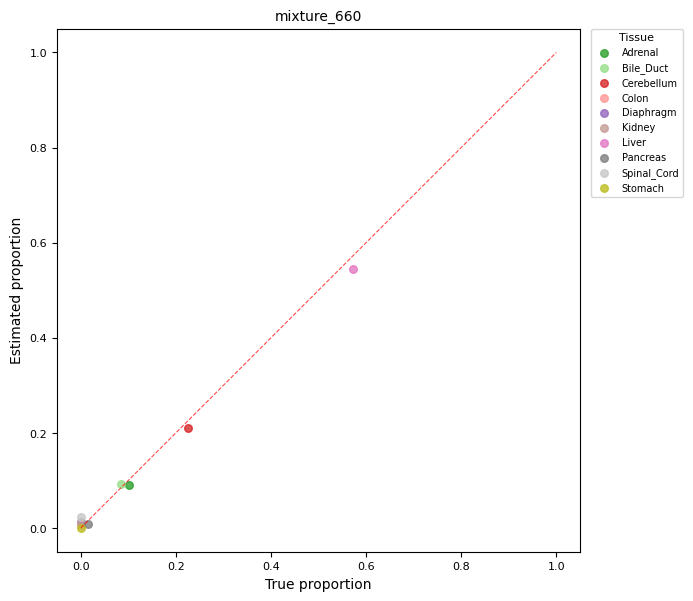

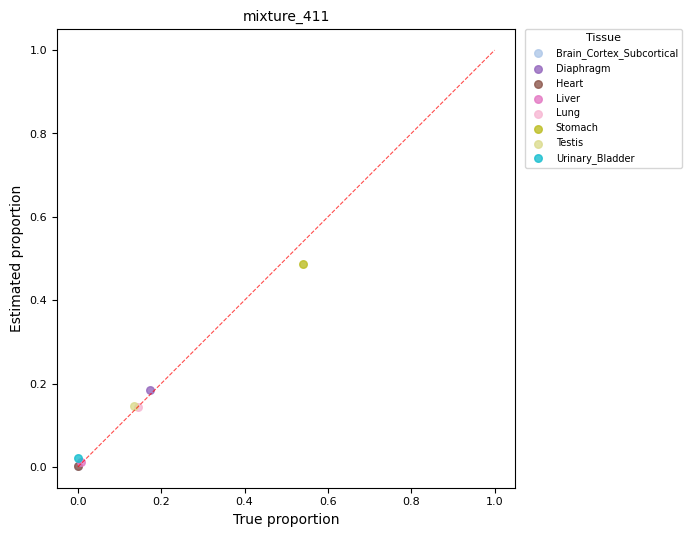

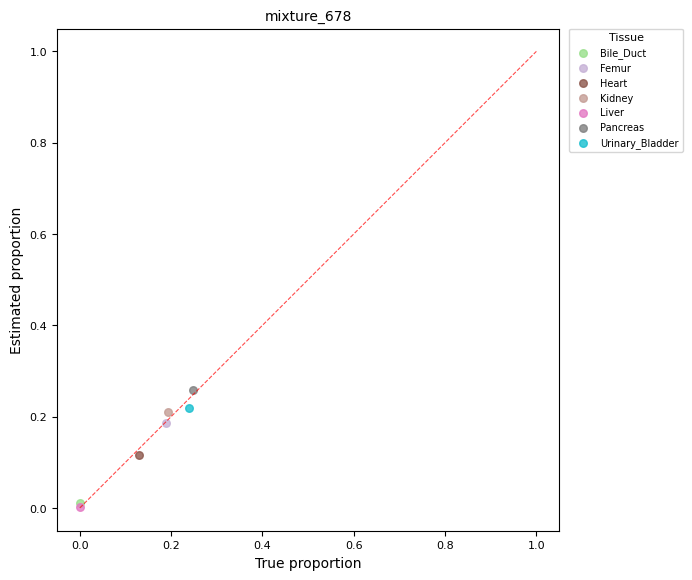

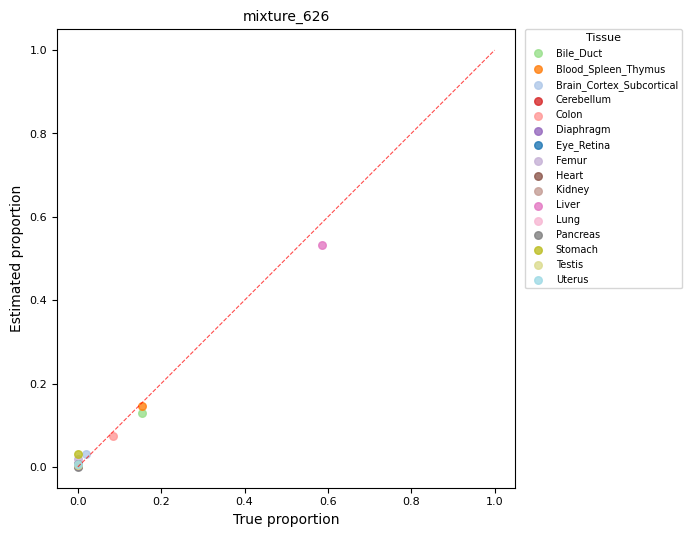

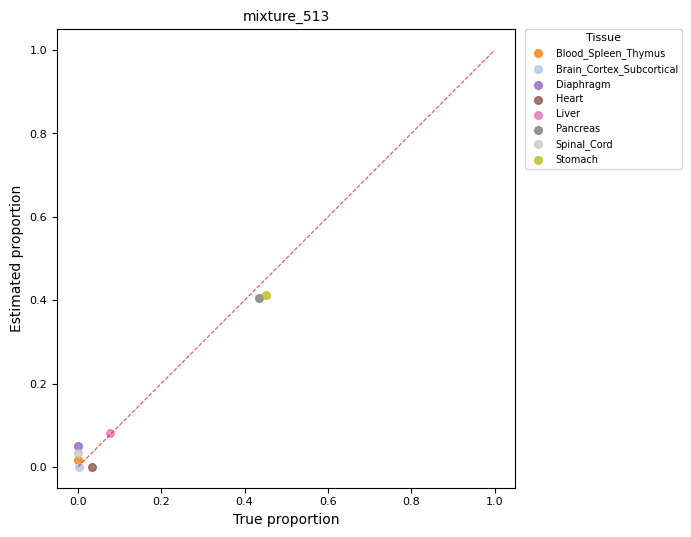

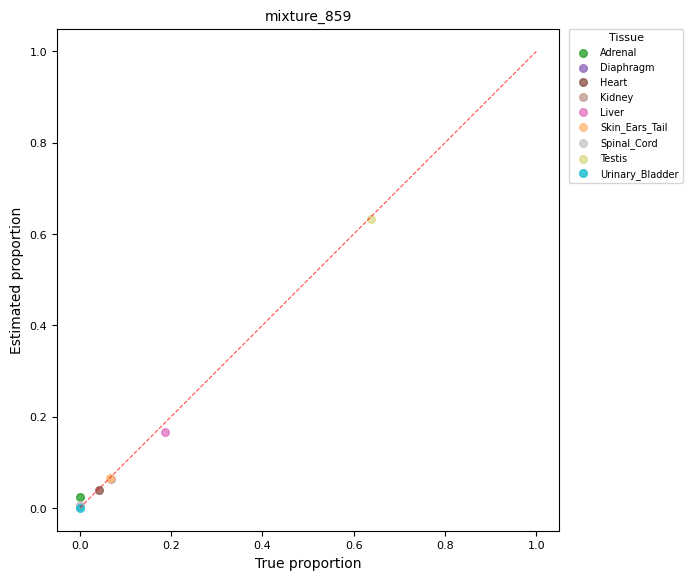

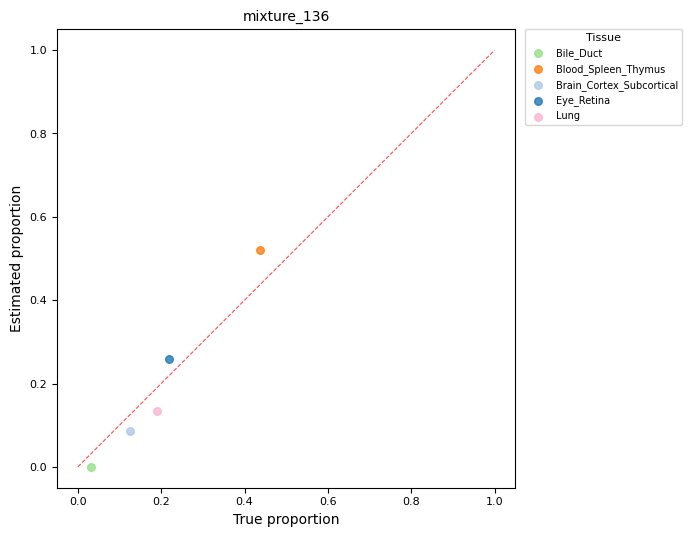

In [8]:

# Step 3: scatter plots for the selected mixtures
plot_selected_mixture_scatters(
    df_proportions=task1["df_proportions"],
    df_estimated=task1["df_estimated"],
    mixture_ids=selected_mixture_ids,
    annotate_points=ANNOTATE_SCATTER_POINTS,
)


/tmp/ipykernel_888361/1123434496.py:260: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(tissues))


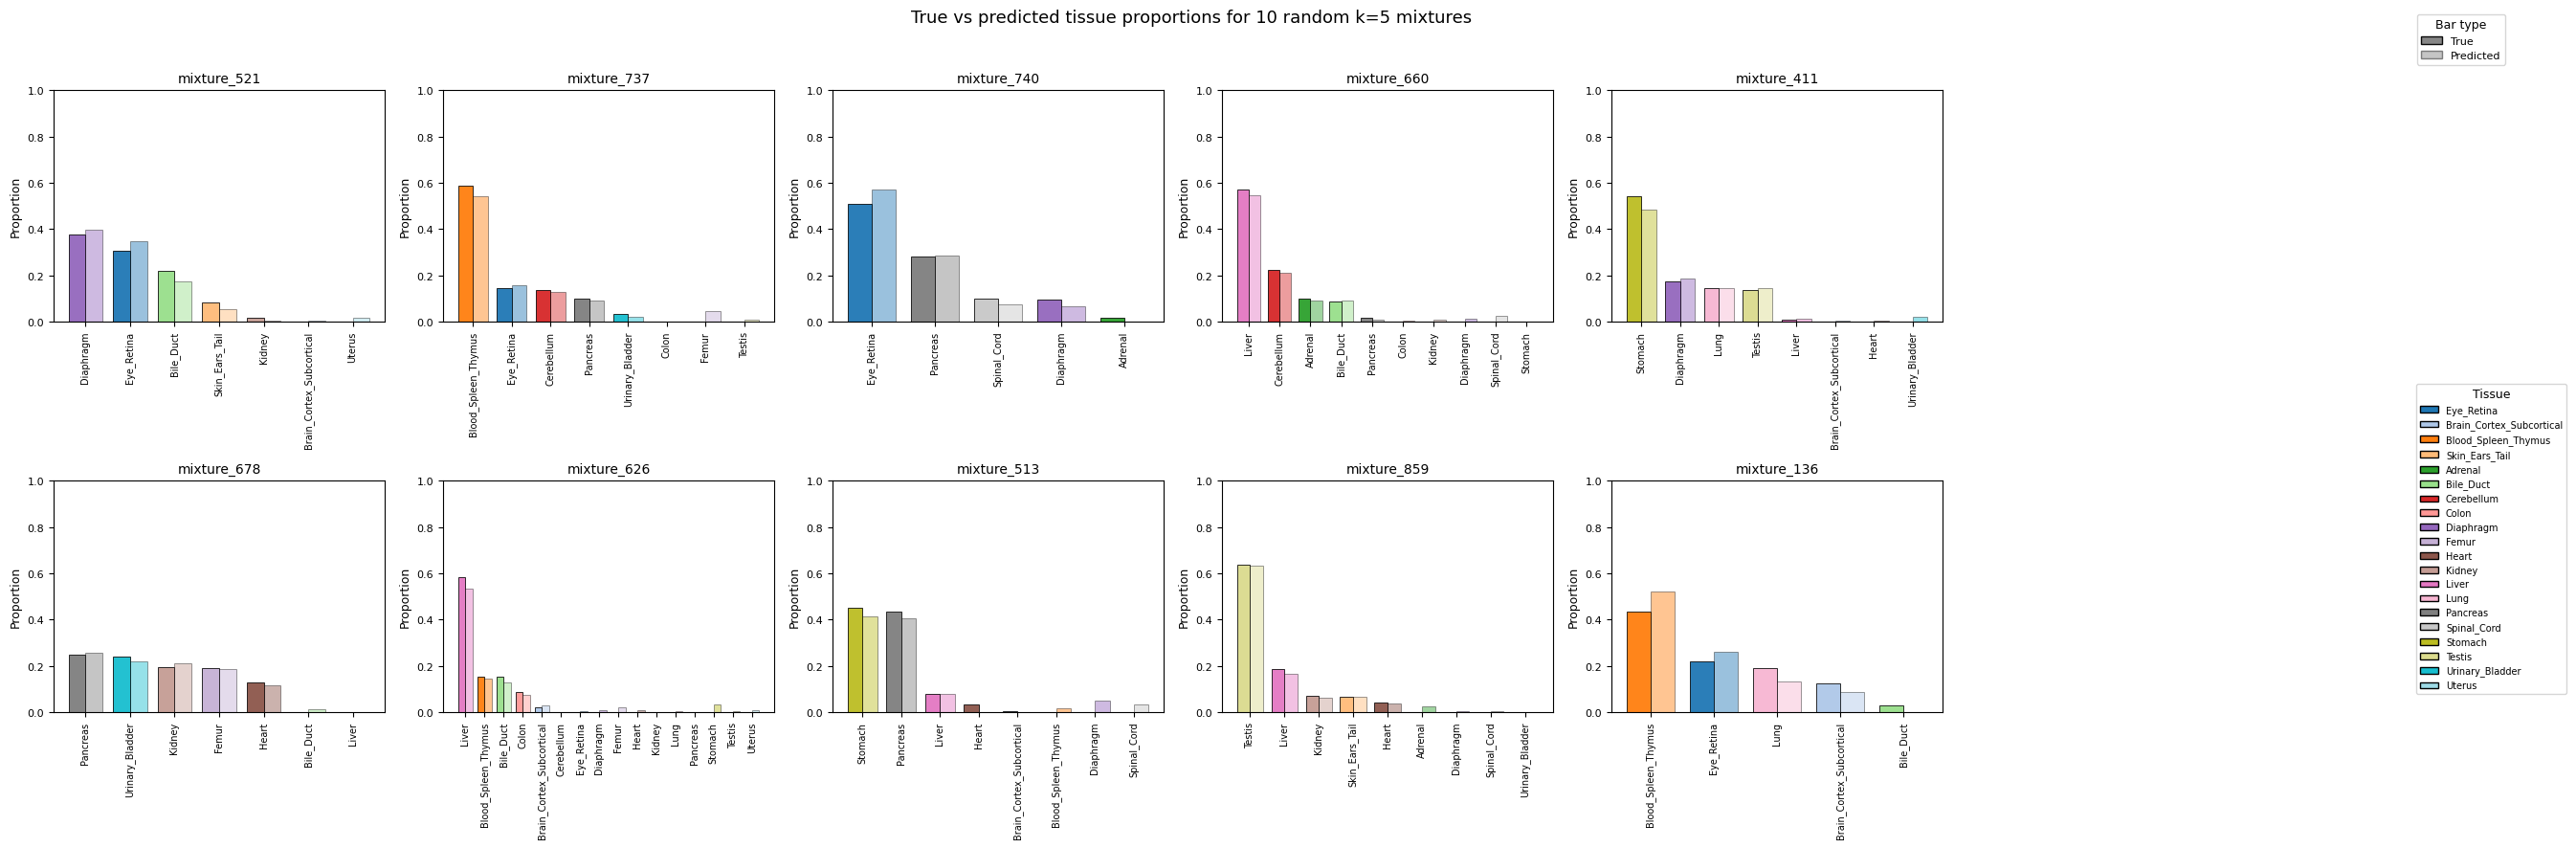

In [9]:

# Step 4: grouped bar plots for the SAME selected mixtures
plot_selected_mixture_barplots(
    df_proportions=task1["df_proportions"],
    df_estimated=task1["df_estimated"],
    mixture_ids=selected_mixture_ids,
)

In [ ]:
"""TASK 2 - NOT WORKING"""

In [10]:
# =========================
# Task 2: MAE for k=2 mixtures
# Boxplot grouped by tissue pair
# =========================

def build_k2_pair_mae_table(
    split_path: Path,
    n_mixtures: int = 1000,
    mixture_seed: int = 123,
) -> tuple[pd.DataFrame, dict]:
    """
    Rerun deconvolution with k=2 mixtures only, then build a table with:
    - mixture_id
    - MAE
    - tissue_pair (alphabetically normalized)
    """
    task2 = prepare_deconv_run_for_notebook(
        split_path=split_path,
        k_min=2,
        k_max=2,
        n_mixtures=n_mixtures,
        mixture_seed=mixture_seed,
    )

    df_proportions = task2["df_proportions"]
    df_mixture_metrics = task2["df_mixture_metrics"]

    records = []
    for mix_id in df_proportions.index:
        true_row = df_proportions.loc[mix_id]

        # Identify the two tissues with non-zero true proportion
        active_tissues = true_row[true_row > 0].index.tolist()

        if len(active_tissues) != 2:
            # Defensive check: for k=2 generation, this should never happen
            continue

        pair_label = "__".join(sorted(active_tissues))

        records.append({
            "mixture_id": mix_id,
            "mae": df_mixture_metrics.loc[mix_id, "mae"],
            "tissue_pair": pair_label,
        })

    df_pair_mae = pd.DataFrame(records)

    return df_pair_mae, task2


def plot_k2_mae_by_tissue_pair(
    df_pair_mae: pd.DataFrame,
    figsize_scale: float = 0.35,
):
    """
    Plot MAE for k=2 mixtures as a boxplot grouped by tissue pair.

    All tissue pairs are shown.
    Pairs are ordered by median MAE so the hardest pairs are easy to spot.
    """
    # Order pairs by median MAE (worst first = left/top)
    order = (
        df_pair_mae
        .groupby("tissue_pair")["mae"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    n_pairs = len(order)
    fig_width = max(14, n_pairs * figsize_scale)

    plt.figure(figsize=(fig_width, 7))
    sns.boxplot(
        data=df_pair_mae,
        x="tissue_pair",
        y="mae",
        order=order,
        color="steelblue",
        showfliers=False,
    )

    # Overlay individual points so spread is visible
    sns.stripplot(
        data=df_pair_mae,
        x="tissue_pair",
        y="mae",
        order=order,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.2,
    )

    plt.xlabel("Tissue pair")
    plt.ylabel("MAE")
    plt.title("k=2 mixtures: MAE grouped by tissue pair")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [11]:

# ---- Run Task 2 ----
df_pair_mae, task2 = build_k2_pair_mae_table(
    split_path=SPLIT_PATH,
    n_mixtures=1000,
    mixture_seed=123,
)


Excluded 20 samples from: {'Mammary_Glands', 'Sciatic_Nerve', 'Optic_Nerve'}
Remaining samples: 247

Sample counts per merged tissue class:
merged_tissue
Adrenal                      6
Bile_Duct                    6
Blood_Spleen_Thymus         30
Brain_Cortex_Subcortical    25
Cerebellum                   9
Colon                       11
Diaphragm                    6
Eye_Retina                  17
Femur                       10
Heart                       10
Kidney                      12
Liver                       26
Lung                        10
Pancreas                     7
Skin_Ears_Tail              31
Spinal_Cord                  6
Stomach                      5
Testis                      10
Urinary_Bladder              6
Uterus                       4
Name: count, dtype: int64
Loaded split from /home/jullid/projects/mouse-DNA-project/results/deconvolution/split.json
  Reference fraction: 0.5
  Split seed: 42
  Reference: 119 samples
  Pool: 128 samples
Reference matrix W sh

  mixture_id       mae                  tissue_pair
0  mixture_0  0.007153  Skin_Ears_Tail__Spinal_Cord
1  mixture_1  0.002630         Cerebellum__Pancreas
2  mixture_2  0.004359          Adrenal__Eye_Retina
3  mixture_3  0.008351           Eye_Retina__Kidney
4  mixture_4  0.008028            Pancreas__Stomach

Number of unique tissue pairs: 171


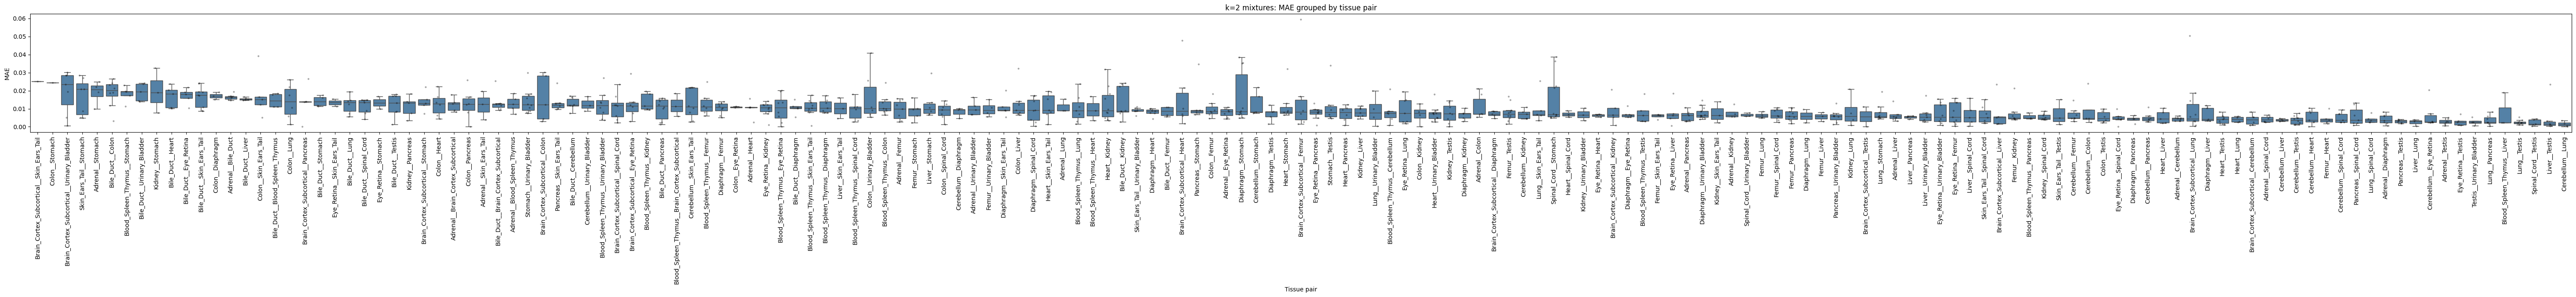

In [12]:

print(df_pair_mae.head())
print(f"\nNumber of unique tissue pairs: {df_pair_mae['tissue_pair'].nunique()}")

plot_k2_mae_by_tissue_pair(df_pair_mae)